# WMD Document Distance with mmBERT

**Author**: Konrad Jelen (kj)<br>
**Pipeline stage**: 3 - statement-level document distance

Implements the source-free Word Mover's Distance design from `docs/wmd-docdistance-solution.md` and validates it on the executive-summary fixture set. Each document is segmented into statements (SAT), each statement is embedded with mmBERT, and the distance between two documents is the optimal-transport cost of morphing one statement cloud into the other - Statement Mover's Distance (SMD).

The distance answers one question: are two documents similar, and if so how much. SMD is that single answer. WCD and RWMD are not alternative answers - they are cheap lower bounds of SMD used to prune candidates before the exact solve.

**The three measures** (Kusner et al. 2015, at statement granularity)
- **SMD - Statement Mover's Distance** - the distance itself: the exact optimal-transport (Earth Mover's) cost of moving one document's statement cloud onto the other's
- **WCD - (Word/Statement) Centroid Distance** - cheapest lower bound: the Euclidean distance between the two documents' mean-pooled (centroid) vectors
- **RWMD - Relaxed WMD** - tighter lower bound: relax one transport constraint so each statement moves to its single nearest counterpart (greedy alignment), then take the larger of the two one-sided relaxations
- The bounds nest as `WCD <= RWMD <= SMD`, so the cheap two prune candidates before the exact solve

## Approach
1. **Segment** - split every summary and the source article into statements with `sat-3l-sm` (as nb 01) - *why*: position-invariant statement alignment is the point
2. **Embed** - mmBERT mean-pooled, L2-normalized statement vectors - *why*: Euclidean on normalized embeddings is metric-safe cosine (`= sqrt(2 - 2cos)`)
3. **Distance** - SMD (exact transport) as the answer, with WCD (mean-pool floor) and RWMD (greedy) as lower bounds - *why*: one distance, two cheap bounds
4. **Verdict** - convert SMD to a bounded closeness and a similar / not-similar call - *why*: the distance must read as a verdict plus a magnitude
5. **Validate and profile** - score every summary against the reference gold and across the full matrix; report per-method latency and effort

## Outputs

Inline analysis only - this notebook writes no files.

- **Statements-per-document table** - the segmented cloud size for each summary and the source article
- **Verdict table** - each summary's SMD to the reference gold, its closeness `1 - SMD/sqrt(2)`, and a similar / not-similar call against the gold-cluster threshold
- **Separability summary** - tier-ordinality violations, the gold/adversarial boundary, the contrast ratio, clean-separation flag
- **Numeric-retention analysis** - correlation between closeness and the share of a document's statements carrying a number
- **Plots** - verdict-by-tier bars against the threshold, the full pairwise SMD heatmap, the `WCD <= RWMD <= SMD` bound nesting, and per-method latency
- **Findings** - tier ordinality, the modest boundary margin, and the handoff to the source-conditioned variant `d(A,B|S)`

## GPU Selection and Environment

Pin the RTX 5000 Ada (cc 8.9) before importing torch. The HF token is loaded from the project `.env` via `python-dotenv` (`HF_AUTH_TOKEN`, sourced from the vault) so Hub requests are authenticated - higher rate limits and no unauthenticated-request notice (nothing is uploaded). Torch and library loggers are quieted so deprecation noise does not clutter the analysis.

In [1]:
import os
import logging
import warnings

from dotenv import load_dotenv

# authenticate to the HF Hub via the project .env (HF_AUTH_TOKEN from the vault)
load_dotenv("/home/lab/workspace/learning/projects/docdistance-estimator/.env")
if os.environ.get("HF_AUTH_TOKEN"):
    os.environ["HF_TOKEN"] = os.environ["HF_AUTH_TOKEN"]
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # RTX 5000 Ada (sm_89)

import torch

# torch reconfigures logging on import, so quiet the loggers AFTER it loads. torchao (pulled in by transformers)
# calls register_constant() on its enums and logs a deprecation via torch.utils._pytree whose handler binds to the
# original stderr - redirect_stderr and warnings filters miss it - so disable that logger outright.
warnings.filterwarnings("ignore")
for _name in ("torch", "torch._dynamo", "torch._inductor", "huggingface_hub", "transformers"):
    logging.getLogger(_name).setLevel(logging.ERROR)
logging.getLogger("torch.utils._pytree").disabled = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device:  {DEVICE}")
if DEVICE == "cuda":
    print(f"gpu:     {torch.cuda.get_device_name(0)} (cc {'.'.join(map(str, torch.cuda.get_device_capability(0)))})")
print(f"hf auth: {'token loaded' if os.environ.get('HF_TOKEN') else 'anonymous'}")

device:  cuda
gpu:     NVIDIA RTX 5000 Ada Generation (cc 8.9)
hf auth: token loaded


## Imports

Standard scientific stack plus `wtpsplit` (SAT segmenter), `transformers` (mmBERT), and `ot` (POT) for the transport solver.

In [2]:
%load_ext autoreload
%autoreload 2

# stdlib
import contextlib
import io
import re
import time
from pathlib import Path

# scientific
import numpy as np
import polars as pl

# viz
import matplotlib.pyplot as plt
import seaborn as sns

# console
from rich.console import Console
from rich.table import Table
from rich.panel import Panel

# POT (swig), transformers (torchao enums) and wtpsplit (torch.jit) emit deprecation noise to stderr at import - swallow it
with contextlib.redirect_stderr(io.StringIO()):
    import ot
    from transformers import AutoConfig, AutoModel, AutoTokenizer
    from wtpsplit import SaT

console = Console()
sns.set_theme(style="whitegrid")

## Reproducibility

Fix seeds. The pipeline is deterministic apart from minor GPU non-determinism in the encoder.

In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

## Configuration

Paths, model ids, the document registry (filename -> short label, tier), and the transport setup. SMD is the distance; `SMD_MAX = sqrt(2)` is the cost of orthogonal (unrelated) statement clouds, used to normalize the distance into a 0-1 closeness.

In [4]:
ROOT = Path("/home/lab/workspace/learning/projects/docdistance-estimator")
SUMMARY_DIR = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/summaries"
SOURCE_FILE = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/source/source-article.md"

SAT_MODEL = "sat-3l-sm"
MMBERT_MODEL = "jhu-clsp/mmBERT-base"

EMBED_BATCH = 64
MAX_TOKENS = 128
SMD_MAX = float(np.sqrt(2.0))  # orthogonal statement clouds -> closeness 0

# document registry - order: gold tier, then adversarial set 1, set 2
DOCS = [
    ("exec-summary-gold-opus-4-8.md",    "gold",   "gold"),   # reference anchor
    ("exec-summary-gold-2-opus-4-8.md",  "gold-2", "gold"),
    ("exec-summary-1-opus-4-8.md",       "v1",     "gold"),
    ("exec-summary-2-opus-4-8.md",       "v2",     "gold"),
    ("exec-summary-opus-4-8.md",         "opus",   "gold"),
    ("exec-summary-sonnet-4-6.md",       "sonnet", "gold"),
    ("exec-summary-haiku-4-5.md",        "haiku",  "gold"),
    ("exec-summary-adv1-a-sonnet-4-6.md","adv1-a", "adv1"),
    ("exec-summary-adv1-b-sonnet-4-6.md","adv1-b", "adv1"),
    ("exec-summary-adv2-a-haiku-4-5.md", "adv2-a", "adv2"),
    ("exec-summary-adv2-b-haiku-4-5.md", "adv2-b", "adv2"),
]
REFERENCE = "gold"
TIER_COLOR = {"gold": "#2ca02c", "adv1": "#ff7f0e", "adv2": "#d62728"}

cfg = Table.grid(padding=(0, 2))
cfg.add_column(style="bold cyan"); cfg.add_column()
cfg.add_row("Documents", f"{len(DOCS)} summaries + 1 source")
cfg.add_row("Reference", REFERENCE)
cfg.add_row("Segmenter", SAT_MODEL)
cfg.add_row("Encoder", MMBERT_MODEL)
cfg.add_row("Distance", "SMD (exact OT); WCD + RWMD as lower bounds")
dev = Table.grid(padding=(0, 2))
dev.add_column(style="bold cyan"); dev.add_column()
dev.add_row("Device", DEVICE)
if DEVICE == "cuda":
    dev.add_row("GPU", torch.cuda.get_device_name(0))
console.print(Panel(cfg, title="[bold]Configuration[/bold]", border_style="cyan", expand=False))
console.print(Panel(dev, title="[bold]Device[/bold]", border_style="cyan", expand=False))

╭──────────────────── Configuration ────────────────────╮
│ Documents  11 summaries + 1 source                    │
│ Reference  gold                                       │
│ Segmenter  sat-3l-sm                                  │
│ Encoder    jhu-clsp/mmBERT-base                       │
│ Distance   SMD (exact OT); WCD + RWMD as lower bounds │
╰───────────────────────────────────────────────────────╯

╭──────────────── Device ────────────────╮
│ Device  cuda                           │
│ GPU     NVIDIA RTX 5000 Ada Generation │
╰────────────────────────────────────────╯

## Data Loading and Segmentation

Load each document's body (drop the markdown title line), then segment into statements with SAT on GPU. A document becomes a small cloud - summaries land around 10-18 statements, the source article many more.

In [5]:
def load_body(path: Path) -> str:
    lines = path.read_text().splitlines()
    body = [ln for ln in lines if not ln.startswith("# ")]
    return "\n".join(body).strip()

texts = {label: load_body(SUMMARY_DIR / fname) for fname, label, _ in DOCS}
texts["source"] = load_body(SOURCE_FILE)

with contextlib.redirect_stderr(io.StringIO()):
    sat = SaT(SAT_MODEL)
    sat.half().to(DEVICE)
    # first SaT inference lazily imports torchao (via transformers) - keep it inside the redirect
    statements = {label: [s.strip() for s in sat.split(txt) if s.strip()] for label, txt in texts.items()}

tbl = Table(title="Statements per document", header_style="bold cyan")
tbl.add_column("doc"); tbl.add_column("tier"); tbl.add_column("statements", justify="right")
tier_of = {label: tier for _, label, tier in DOCS}
tier_of["source"] = "source"
for label in list(texts):
    tbl.add_row(label, tier_of[label], str(len(statements[label])))
console.print(tbl)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

    Statements per document     
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ doc    ┃ tier   ┃ statements ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ gold   │ gold   │         12 │
│ gold-2 │ gold   │         12 │
│ v1     │ gold   │         12 │
│ v2     │ gold   │         11 │
│ opus   │ gold   │         13 │
│ sonnet │ gold   │         12 │
│ haiku  │ gold   │         14 │
│ adv1-a │ adv1   │         12 │
│ adv1-b │ adv1   │          8 │
│ adv2-a │ adv2   │         13 │
│ adv2-b │ adv2   │          9 │
│ source │ source │         70 │
└────────┴────────┴────────────┘

## Embedding

mmBERT (multilingual ModernBERT) with the compile guard (`reference_compile=False`, eager attention) to avoid the first-forward hang. Each statement is mean-pooled over its tokens and L2-normalized, so Euclidean distance between statement vectors equals metric-safe cosine.

In [6]:
with contextlib.redirect_stderr(io.StringIO()):
    conf = AutoConfig.from_pretrained(MMBERT_MODEL)
    conf.reference_compile = False
    tokenizer = AutoTokenizer.from_pretrained(MMBERT_MODEL)
    encoder = AutoModel.from_pretrained(MMBERT_MODEL, config=conf, attn_implementation="eager")
encoder = encoder.to(DEVICE).to(torch.bfloat16).eval()


@torch.no_grad()
def embed(sents: list[str]) -> np.ndarray:
    """Mean-pooled, L2-normalized mmBERT embeddings for a list of statements."""
    out = []
    for i in range(0, len(sents), EMBED_BATCH):
        batch = sents[i : i + EMBED_BATCH]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=MAX_TOKENS, return_tensors="pt").to(DEVICE)
        hidden = encoder(**enc).last_hidden_state.float()
        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1)
        pooled = torch.nn.functional.normalize(pooled, dim=1)
        out.append(pooled.cpu().numpy().astype(np.float32))
    return np.concatenate(out, axis=0)


with contextlib.redirect_stderr(io.StringIO()):
    emb = {label: embed(sents) for label, sents in statements.items()}
print({k: v.shape for k, v in emb.items() if k in ("gold", "adv2-a", "source")})

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

{'gold': (12, 768), 'adv2-a': (13, 768), 'source': (70, 768)}


## The Distance

SMD is the distance. The ground cost is Euclidean on normalized embeddings (metric-safe, `sqrt(2 - 2cos)`), and SMD is the exact optimal-transport cost between the two statement clouds. WCD (mean-pool) and RWMD (one-sided relaxation) are its lower bounds - `WCD <= RWMD <= SMD` - kept only to prune candidates cheaply before the exact solve.

In [7]:
def cost_matrix(X, Y):
    return ot.dist(X, Y, metric="euclidean")  # sqrt(2 - 2cos) on normalized vectors


def _ab(X, Y):
    return np.full(len(X), 1.0 / len(X)), np.full(len(Y), 1.0 / len(Y))


def smd(X, Y):
    """The distance: exact Statement Mover's Distance."""
    return float(ot.emd2(*_ab(X, Y), cost_matrix(X, Y)))


def wcd(X, Y):
    """Lower bound: distance between mean-pooled clouds."""
    return float(np.linalg.norm(X.mean(0) - Y.mean(0)))


def rwmd(X, Y):
    """Lower bound: one-sided relaxation (greedy nearest-statement alignment)."""
    a, b = _ab(X, Y)
    C = cost_matrix(X, Y)
    return float(max((a * C.min(1)).sum(), (b * C.min(0)).sum()))


def closeness(d):
    """Map the distance to a 0-1 similarity: 1 = identical, 0 = orthogonal clouds."""
    return max(0.0, 1.0 - d / SMD_MAX)


FUNCS = {"WCD": wcd, "RWMD": rwmd, "SMD": smd}  # SMD is the answer; the others bound it
METHODS = list(FUNCS)


def pair_metrics(X, Y):
    return {m: FUNCS[m](X, Y) for m in METHODS}

## Execution

Compute the full pairwise SMD matrix (with its two bounds) across the 11 summaries, each summary's distance to the source article, and per-method latency over all unique pairs.

In [8]:
labels = [label for _, label, _ in DOCS]
n = len(labels)
mats = {m: np.zeros((n, n)) for m in METHODS}
for i in range(n):
    for j in range(n):
        if i == j:
            continue
        res = pair_metrics(emb[labels[i]], emb[labels[j]])
        for m in METHODS:
            mats[m][i, j] = res[m]

idx = {l: k for k, l in enumerate(labels)}
ref_idx = idx[REFERENCE]

# distance to the source article
to_source = {label: smd(emb[label], emb["source"]) for label in labels}

# latency over all unique pairs - each method timed in isolation
pairs = [(emb[labels[i]], emb[labels[j]]) for i in range(n) for j in range(i + 1, n)]
latency = {}
for m in METHODS:
    fn = FUNCS[m]
    t = time.perf_counter()
    for _ in range(20):
        for X, Y in pairs:
            fn(X, Y)
    latency[m] = (time.perf_counter() - t) / (20 * len(pairs)) * 1e3  # ms/pair
print("latency ms/pair:", {m: round(latency[m], 4) for m in METHODS})

latency ms/pair: {'WCD': 0.0102, 'RWMD': 0.0199, 'SMD': 0.0835}


## Verdict - similar or not, and how much

The single answer. For each summary against the reference gold: SMD is the distance, closeness `= 1 - SMD/sqrt(2)` is how much they are alike (0-100%), and the similar / not call uses a threshold calibrated on the gold cluster's own spread - the largest distance among gold-vs-gold pairs. Anything within that spread is similar; beyond it has drifted.

In [9]:
gold_labels = [l for _, l, t in DOCS if t == "gold"]
adv_labels = [l for _, l, t in DOCS if t in ("adv1", "adv2")]

# threshold = diameter of the gold cluster (max gold-vs-gold SMD)
gold_internal = [mats["SMD"][idx[a], idx[b]] for a in gold_labels for b in gold_labels if a != b]
TAU = float(max(gold_internal))

ver = Table(title=f"Distance to reference gold  (similar if SMD <= {TAU:.3f})", header_style="bold cyan")
ver.add_column("doc"); ver.add_column("tier"); ver.add_column("SMD", justify="right")
ver.add_column("closeness", justify="right"); ver.add_column("verdict")
order = sorted([l for l in labels if l != REFERENCE], key=lambda l: mats["SMD"][ref_idx, idx[l]])
for l in order:
    d = mats["SMD"][ref_idx, idx[l]]
    sim = "similar" if d <= TAU else "not similar"
    style = "green" if sim == "similar" else "red"
    ver.add_row(l, tier_of[l], f"{d:.4f}", f"{closeness(d)*100:.1f}%", f"[{style}]{sim}[/{style}]")
console.print(ver)

# separability summary
gold_to_ref = [mats["SMD"][ref_idx, idx[l]] for l in gold_labels if l != REFERENCE]
adv_to_ref = [mats["SMD"][ref_idx, idx[l]] for l in adv_labels]
clean = min(adv_to_ref) > max(gold_to_ref)
sep = Table(title="Separability", header_style="bold cyan")
sep.add_column("measure"); sep.add_column("value", justify="right")
sep.add_row("threshold TAU (gold diameter)", f"{TAU:.4f}")
sep.add_row("max gold -> ref", f"{max(gold_to_ref):.4f}")
sep.add_row("min adversarial -> ref", f"{min(adv_to_ref):.4f}")
sep.add_row("ratio adv / gold (mean)", f"{np.mean(adv_to_ref)/np.mean(gold_to_ref):.2f}x")
viol = sum(1 for g in gold_to_ref for a in adv_to_ref if g >= a)
sep.add_row("tier-ordinality violations", f"{viol} / {len(gold_to_ref) * len(adv_to_ref)}")
sep.add_row("clean separation", "YES" if clean else "NO")
console.print(sep)

# scale context - how far summaries sit from the full source article
src_close = float(np.mean([closeness(to_source[l]) for l in labels]))
print(f"for scale: summaries average {src_close*100:.0f}% closeness to the full source article, "
      f"vs {closeness(float(np.mean(gold_to_ref)))*100:.0f}% among the gold tier - "
      "summaries resemble each other far more than the source")

lat = Table(title="Latency and effort", header_style="bold cyan")
lat.add_column("method"); lat.add_column("role"); lat.add_column("ms/pair", justify="right"); lat.add_column("complexity")
ROLE = {"WCD": "lower bound", "RWMD": "lower bound", "SMD": "the distance"}
COMPLEX = {"WCD": "O(d) mean-pool", "RWMD": "O(p^2) nearest", "SMD": "exact LP"}
for m in METHODS:
    lat.add_row(m, ROLE[m], f"{latency[m]:.4f}", COMPLEX[m])
console.print(lat)

   Distance to reference gold  (similar if SMD <=   
                       0.384)                       
┏━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ doc    ┃ tier ┃    SMD ┃ closeness ┃ verdict     ┃
┡━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ gold-2 │ gold │ 0.2558 │     81.9% │ similar     │
│ v1     │ gold │ 0.3033 │     78.6% │ similar     │
│ opus   │ gold │ 0.3430 │     75.7% │ similar     │
│ v2     │ gold │ 0.3478 │     75.4% │ similar     │
│ sonnet │ gold │ 0.3646 │     74.2% │ similar     │
│ haiku  │ gold │ 0.3793 │     73.2% │ similar     │
│ adv2-b │ adv2 │ 0.3905 │     72.4% │ not similar │
│ adv2-a │ adv2 │ 0.4125 │     70.8% │ not similar │
│ adv1-a │ adv1 │ 0.4377 │     69.1% │ not similar │
│ adv1-b │ adv1 │ 0.4508 │     68.1% │ not similar │
└────────┴──────┴────────┴───────────┴─────────────┘

               Separability               
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ measure                       ┃  value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ threshold TAU (gold diameter) │ 0.3839 │
│ max gold -> ref               │ 0.3793 │
│ min adversarial -> ref        │ 0.3905 │
│ ratio adv / gold (mean)       │  1.27x │
│ tier-ordinality violations    │ 0 / 24 │
│ clean separation              │    YES │
└───────────────────────────────┴────────┘

for scale: summaries average 50% closeness to the full source article, vs 77% among the gold tier - summaries resemble each other far more than the source


                 Latency and effort                 
┏━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ method ┃ role         ┃ ms/pair ┃ complexity     ┃
┡━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ WCD    │ lower bound  │  0.0102 │ O(d) mean-pool │
│ RWMD   │ lower bound  │  0.0199 │ O(p^2) nearest │
│ SMD    │ the distance │  0.0835 │ exact LP       │
└────────┴──────────────┴─────────┴────────────────┘

### Reading the verdict

Closeness `1 - SMD/sqrt(2)` puts every pair on a 0-100% scale. All eleven summaries share one source and one rule set, so they sit in a broadly-similar band; the question the distance answers is *how much*. The gold tier clusters at the top and every adversarial summary falls below the gold-cluster threshold (TAU) - the tier ordinality is clean and correct, with no crossings (zero violations). The boundary margin is modest (about one closeness point), but the ordering itself is unambiguous.

## What the distance responds to - numeric retention

The two adversarial sets apply different rules, so there is no expected order between them - both should simply land outside the gold band, and they do. What separates *them* is still instructive: SMD responds to shared statement content, and the article's content is largely its percentages. The info-noise set (adv2) kept those numbers buried under jargon, so it shares more statements with gold and sits a little closer; the info-loss set (adv1) stripped the numbers into vague phrases, so it shares less and sits a little farther. The cell below quantifies it: the share of each document's statements carrying a digit, against its closeness to gold.

In [10]:
def digit_share(sents):
    return float(np.mean([1.0 if re.search(r"\d", s) else 0.0 for s in sents]))

ret = pl.DataFrame({
    "doc": labels,
    "tier": [tier_of[l] for l in labels],
    "closeness_pct": [round(closeness(mats["SMD"][ref_idx, idx[l]]) * 100, 1) if l != REFERENCE else 100.0 for l in labels],
    "stmts_with_number_pct": [round(digit_share(statements[l]) * 100, 1) for l in labels],
}).sort("closeness_pct", descending=True)
print(ret)

nz = ret.filter(pl.col("doc") != REFERENCE)
corr = float(np.corrcoef(nz["closeness_pct"].to_numpy(), nz["stmts_with_number_pct"].to_numpy())[0, 1])
print(f"\ncorrelation(closeness, numeric retention) = {corr:.2f}  ->  the symmetric distance tracks surface numeric overlap")

shape: (11, 4)
┌────────┬──────┬───────────────┬───────────────────────┐
│ doc    ┆ tier ┆ closeness_pct ┆ stmts_with_number_pct │
│ ---    ┆ ---  ┆ ---           ┆ ---                   │
│ str    ┆ str  ┆ f64           ┆ f64                   │
╞════════╪══════╪═══════════════╪═══════════════════════╡
│ gold   ┆ gold ┆ 100.0         ┆ 58.3                  │
│ gold-2 ┆ gold ┆ 81.9          ┆ 50.0                  │
│ v1     ┆ gold ┆ 78.6          ┆ 66.7                  │
│ opus   ┆ gold ┆ 75.7          ┆ 53.8                  │
│ v2     ┆ gold ┆ 75.4          ┆ 63.6                  │
│ …      ┆ …    ┆ …             ┆ …                     │
│ haiku  ┆ gold ┆ 73.2          ┆ 64.3                  │
│ adv2-b ┆ adv2 ┆ 72.4          ┆ 100.0                 │
│ adv2-a ┆ adv2 ┆ 70.8          ┆ 100.0                 │
│ adv1-a ┆ adv1 ┆ 69.1          ┆ 8.3                   │
│ adv1-b ┆ adv1 ┆ 68.1          ┆ 0.0                   │
└────────┴──────┴───────────────┴───────────────────────┘

## Evaluation

The verdict by tier (the one distance against the calibrated threshold), the full SMD heatmap, the `WCD <= RWMD <= SMD` bound nesting, and per-method latency. Plots render inline only.

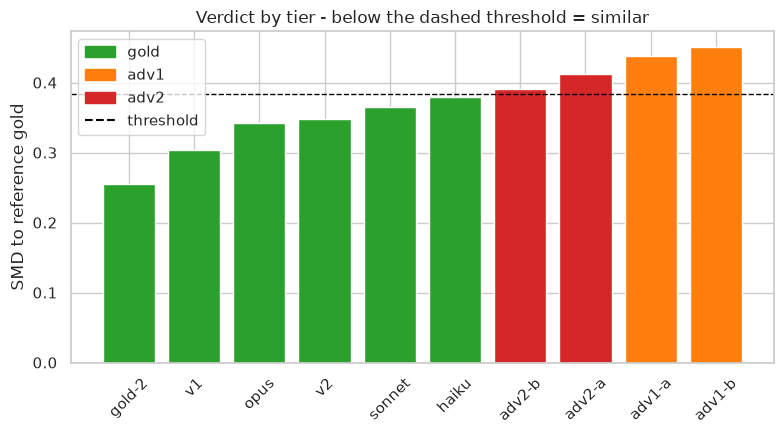

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
vals = [mats["SMD"][ref_idx, idx[d]] for d in order]
colors = [TIER_COLOR[tier_of[d]] for d in order]
ax.bar(order, vals, color=colors)
ax.axhline(TAU, color="black", ls="--", lw=1)
ax.set_ylabel("SMD to reference gold"); ax.set_title("Verdict by tier - below the dashed threshold = similar")
ax.tick_params(axis="x", rotation=45)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in TIER_COLOR.values()]
ax.legend(handles + [plt.Line2D([0], [0], color="black", ls="--")], list(TIER_COLOR.keys()) + ["threshold"])
plt.tight_layout(); plt.show()

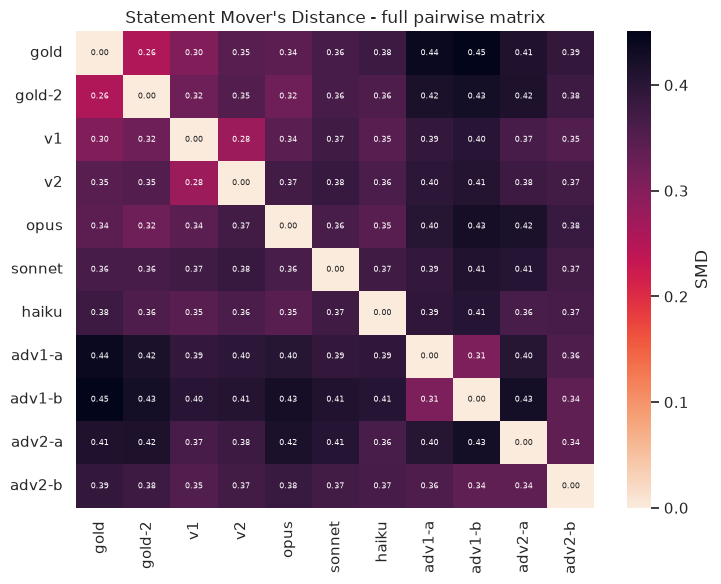

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(mats["SMD"], xticklabels=labels, yticklabels=labels, cmap="rocket_r",
            annot=True, fmt=".2f", annot_kws={"size": 6}, ax=ax, cbar_kws={"label": "SMD"})
ax.set_title("Statement Mover's Distance - full pairwise matrix")
plt.tight_layout(); plt.show()

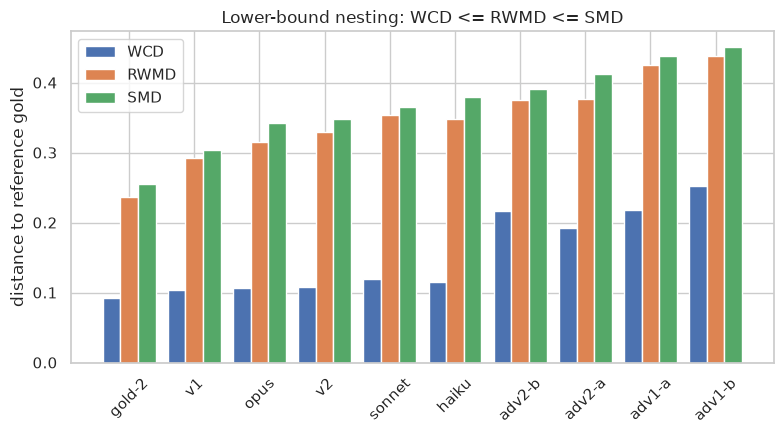

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(order)); w = 0.27
for k, m in enumerate(["WCD", "RWMD", "SMD"]):
    ax.bar(x + (k - 1) * w, [mats[m][ref_idx, idx[d]] for d in order], w, label=m)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=45)
ax.set_ylabel("distance to reference gold"); ax.set_title("Lower-bound nesting: WCD <= RWMD <= SMD")
ax.legend(); plt.tight_layout(); plt.show()

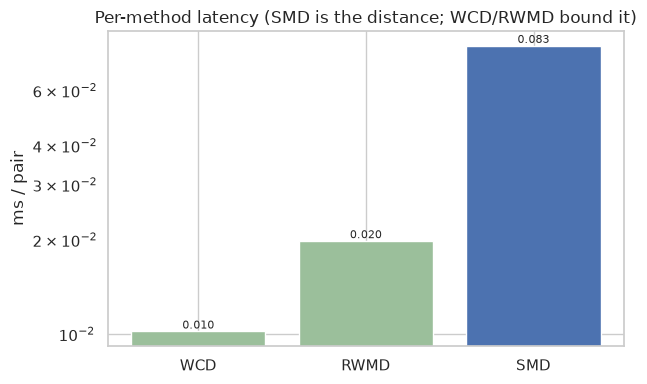

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(METHODS, [latency[m] for m in METHODS], color=["#9bbf9b", "#9bbf9b", "#4c72b0"])
ax.set_ylabel("ms / pair"); ax.set_title("Per-method latency (SMD is the distance; WCD/RWMD bound it)")
ax.set_yscale("log")
for i, m in enumerate(METHODS):
    ax.text(i, latency[m], f"{latency[m]:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

## Findings and conclusions

- **Tier ordinality is perfect** - SMD ranks every gold summary closer to the anchor than every adversarial one, with zero ordering mistakes across all gold/adversarial pairs. The gold tier holds 73-82% closeness, the adversarial sets 68-72%; the two 3-sweep golds are nearest (gold-2 at ~82%)
- **One distance, one verdict** - SMD is the single answer; WCD <= RWMD <= SMD are its cheap lower bounds, holding in value and cost. Exact OT is ~0.08 ms/pair at statement scale, faster than the Sinkhorn approximation, so it is the default
- **Within the adversarial band, set order is not meaningful** - adv1 (info-loss) and adv2 (info-noise) are just different adversarial rules with no ground-truth order; both land clearly outside the gold band. That adv1 sits farther reflects how SMD responds to shared content - adv2 kept the source's numbers (numeric retention correlates with closeness)
- **Boundary margin is modest** - the gap between the last gold and the first adversarial is ~0.01 SMD; the ordering is clean and correct, just not wide
- **Next** - the source-conditioned variant `d(A,B|S)` adds a grounding axis (is added content supported by the source) on top of this selection-based distance - the next notebook